# Lab 3 — Support Vector Machines

## Part 1 — Linear SVM from Scratch

In Lab 2, we implemented linear and logistic regression using individual
functions and gradient descent.

In this notebook we take the next step: instead of a handful of loose
functions, we build a **reusable machine-learning estimator** — the same
`fit` / `predict` pattern you've already used with `sklearn` models. Now
you'll build one yourself.

We will implement a **linear soft-margin Support Vector Machine (SVM)**
from scratch using the **primal formulation**, trained with (sub)gradient
descent. This is different from how `sklearn.svm.SVC` solves the problem
internally (it solves the *dual* problem via quadratic programming), but
both are optimizing the same underlying objective — which is exactly why
we compare the two near the end.

### What you'll build, section by section

1. **Soft-margin SVM** — the objective we're optimizing, and why it's shaped the way it is.
2. **Hinge loss** — the piece that penalizes margin violations.
3. **SVM cost** — hinge loss combined with the margin-maximizing regularizer.
4. **Subgradient** — the descent direction we optimize with, since the
   objective isn't differentiable everywhere.
5. **`LinearSVM` estimator** — wraps 2–4 into a class with `fit` / `predict`.
6. **Effect of `C`** — a small experiment showing what the hyperparameter
   actually does.
7. **Sanity check against `sklearn.svm.SVC`** — do the two agree?

By the end, you'll have a model that follows the familiar estimator
interface:

```python
model = LinearSVM(...)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
```

Your implementations of `hinge_loss`, `svm_cost`, `svm_gradient`, and
`LinearSVM` are checked by hidden tests as part of grading — they aren't
visible in this notebook, so the only way to know your implementation is
correct is to reason through the math and check your results make sense
(e.g. does accuracy improve as you'd expect, does the loss curve trend
downward). Grading runs automatically once you push to your repo.


## Setup

We'll work with a synthetic **employee attrition** dataset: the task is
to predict whether an employee leaves the company (`Attrition`) from a
mix of numeric and categorical HR features (department, education level,
remote-work status, years of experience, performance score, salary).

First, the standard imports — `numpy`/`pandas` for data handling,
`matplotlib` for plotting, and a few `sklearn` utilities we'll reuse
(`StandardScaler`, `train_test_split`, `accuracy_score`, and `SVC` for
the comparison in Section 7).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC


## Preparing the Dataset

A few choices below are deliberate, not arbitrary — they're the same
data-leakage precautions you should apply in any supervised-learning
pipeline:

- **One-hot encode categoricals before splitting.** This is safe
  *before* the split because it's a structural transformation (turning
  a category into 0/1 columns) that doesn't depend on any statistic of
  the data — unlike scaling or imputing, it can't leak information from
  the test set into training.
- **Split before computing anything statistical.** `train_test_split`
  runs first, before we touch missing values or scale features.
- **Impute missing values using train-only statistics.** `YearsExperience`
  and `PerformanceScore` have missing values; we fill them with the
  *median computed on the training set only*, then apply that same
  number to the test set. Computing the median on the full dataset would
  leak test-set information into training.
- **Scale using train-only statistics.** Same idea: `StandardScaler` is
  fit on `X_train` only, then applied (not re-fit) to `X_test`.
- **Labels become `{-1, +1}`, not `{0, 1}`.** `Attrition == "Yes"` maps
  to `+1`, everything else to `-1` — this is the label convention the
  SVM math in Section 1 assumes. (`y_salary` is extracted here too but
  isn't used in this notebook — it's left in case you want to reuse this
  same preprocessing for a regression task later.)



In [3]:
df = pd.read_csv("/kaggle/working/lab-3-svm/employee_data.csv")

cat_cols = ["Department", "EducationLevel", "RemoteStatus"]
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)  # encoding is safe pre-split - it's structural, not statistical
df_encoded["Attrition"] = np.where(df_encoded["Attrition"] == "Yes", 1, -1)

feature_cols = [c for c in df_encoded.columns if c not in ("Salary", "Attrition")]
X = df_encoded[feature_cols].to_numpy(dtype=float)
y_salary = df_encoded["Salary"].to_numpy()
y_attrition = df_encoded["Attrition"].to_numpy()

# split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y_attrition, test_size=0.2, random_state=1
)

# impute using TRAIN-only medians
exp_idx = feature_cols.index("YearsExperience")
perf_idx = feature_cols.index("PerformanceScore")
exp_median = np.nanmedian(X_train[:, exp_idx])
perf_median = np.nanmedian(X_train[:, perf_idx])
X_train[np.isnan(X_train[:, exp_idx]), exp_idx] = exp_median
X_test[np.isnan(X_test[:, exp_idx]), exp_idx] = exp_median
X_train[np.isnan(X_train[:, perf_idx]), perf_idx] = perf_median
X_test[np.isnan(X_test[:, perf_idx]), perf_idx] = perf_median

# scale, fit on TRAIN only
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
# labels are in {-1, +1}, so we can't just take the mean like a 0/1 rate
print("Attrition positive rate (train):", round((y_train == 1).mean(), 3))


X_train: (400, 8)  X_test: (100, 8)
Attrition positive rate (train): 0.3


---

## 1. Soft-Margin SVM

### The setup

For binary classification, we use labels:

$$
y_i \in \{-1,+1\}.
$$

(Not $\{0, 1\}$ — this matters, because the SVM math below relies on
multiplying $y_i$ by the model's output, and that trick only works with
$\pm 1$ labels.)

The decision function is a linear function of the input:

$$
f(x)=w^Tx+b.
$$

The predicted class is just the sign of this value:

$$
\hat y = \operatorname{sign}(f(x)).
$$

Geometrically, $w^Tx+b=0$ defines a hyperplane that splits the feature
space in two. $w$ is the vector perpendicular to that hyperplane, and
$b$ shifts it away from the origin.

### Why margin, and why $\|w\|$

A hyperplane that separates two classes isn't unique — many hyperplanes
could do it. The SVM picks the one with the largest **margin**: the
distance from the hyperplane to the nearest point of either class. It
turns out that margin width is exactly $2/\|w\|$, so **minimizing
$\|w\|$ is the same as maximizing the margin**. That's why the
objective below has a $\frac{1}{2}\|w\|^2$ term — it's not an
arbitrary regularizer, it's the margin itself, written in a
gradient-friendly form.

### Why "soft" margin

Real data usually isn't perfectly separable. A **hard**-margin SVM would
have no solution if any point violates the margin. A **soft**-margin SVM
instead allows violations, but penalizes them — that's the role of the
**hinge loss** term below. The soft-margin SVM minimizes:

$$
J(w,b)
=
\frac{1}{2}\|w\|^2
+
C\frac{1}{n}
\sum_{i=1}^{n}
\max(0,1-y_i(w^Tx_i+b)).
$$

- The **first term** ($\frac{1}{2}\|w\|^2$) rewards a wide margin.
- The **second term** (the mean hinge loss) penalizes points that fall
  inside the margin or are misclassified.
- $C$ controls the trade-off: **small $C$** prioritizes a wide
  margin and tolerates more violations (simpler, more regularized model);
  **large $C$** prioritizes classifying every training point correctly,
  even if it means a narrower margin (can overfit). You'll see this
  directly in Section 6.


## 2. Hinge Loss

### Intuition

For a single training example, the hinge loss is:

$$
L_i =
\max(0,1-y_i(w^Tx_i+b)).
$$

Look at what $y_i(w^Tx_i+b)$ means: it's positive when the prediction
agrees with the true label, and its *size* tells you how confidently /
how far past the margin the point sits.

- If $y_i(w^Tx_i+b) \ge 1$: the point is correctly classified **and**
  sits on or outside the margin. No penalty — $L_i = 0$.
- If $0 \le y_i(w^Tx_i+b) < 1$: correctly classified, but inside the
  margin. Small penalty.
- If $y_i(w^Tx_i+b) < 0$: misclassified. Larger penalty, growing
  linearly the further wrong it is.

This is what makes it a "hinge" — flat at zero, then a straight line, with
a kink at $y_i(w^Tx_i+b) = 1$.

### What to implement

Implement `hinge_loss(w, b, X, y)`:

1. Compute the raw decision scores `X @ w + b` for every row of `X`.
2. Multiply elementwise by `y` to get the per-sample margins.
3. Apply `max(0, 1 - margin)` elementwise (use `np.maximum`, not
   Python's built-in `max`, so it works on the whole array at once).
4. Return the **mean** hinge loss over all samples — not the sum.

Everything here should be vectorized with NumPy; you shouldn't need a
Python `for` loop over samples.


In [5]:
### START CODE HERE ### (~ 1 line of code)
def hinge_loss(w, b, X, y):
    margins =y* (X @ w + b)
    l = np.mean(np.maximum(0, 1 - margins))
    return l
### END CODE HERE ###

## 3. Soft-Margin SVM Objective

Now combine the margin term and the hinge-loss term from Section 1 into
the full objective:

$$
J(w,b)
=
\frac{1}{2}\|w\|^2
+
C \cdot \text{hinge\_loss}.
$$

### What to implement

Implement `svm_cost(w, b, X, y, C)`. Concretely:

1. Compute the mean hinge loss the same way you did in Section 2 (you can
   either call your `hinge_loss` function directly, or recompute the same
   three lines inline — both are fine).
2. Compute $\frac{1}{2}\|w\|^2$ — this is `0.5 * (w @ w)` or
   `0.5 * np.dot(w, w)`, **not** `0.5 * np.linalg.norm(w)` (that would be
   $\|w\|$, not $\|w\|^2$).
3. Return their sum, with the hinge loss scaled by `C`.

Note that `b` doesn't appear in the regularization term — only `w` is
penalized. This is standard for SVMs: only the orientation of the
hyperplane should be kept simple, not its offset from the origin.


In [6]:
### START CODE HERE ### (~ 3 lines of code)
def svm_cost(w, b, X, y, C):
    """
    Compute the regularized SVM objective.
    """
    margins = y * (X @ w + b)
    hinge = np.mean(np.maximum(0, 1 - margins))
    return 0.5 * (w @ w) + C * hinge

## 4. Subgradient of the SVM Objective

### Why a *sub*gradient, not a gradient

The hinge loss has a kink — it isn't differentiable at:

$$
y_i(w^Tx_i+b)=1.
$$

Away from that point it's piecewise linear, so we can still take a
gradient on each piece; at the kink itself we just pick one of the valid
subgradients (here, treating it the same as the "no violation" side is
the standard convention, and is what the mask below does).

### Deriving it

Split the objective into two pieces:

- $\frac{1}{2}\|w\|^2$ is always differentiable:
  $\nabla_w = w$, and it doesn't depend on $b$ at all.
- The hinge-loss term only contributes where a sample **violates** the
  margin, i.e. where $y_i(w^Tx_i+b) < 1$. Call this set the
  **active set**. For samples in the active set, the hinge loss
  contributes $-y_i x_i$ to $\nabla_w$ and $-y_i$ to
  $\nabla_b$ (scaled by $C/n$); for every other sample it
  contributes exactly $0$.

Putting it together, for a batch of $m$ samples:

$$
\nabla_w J = w - \frac{C}{m}\sum_{i \in \text{active}} y_i x_i,
\qquad
\nabla_b J = -\frac{C}{m}\sum_{i \in \text{active}} y_i.
$$

### What to implement

Implement `svm_gradient(w, b, X, y, C)`, returning `dw, db`:

1. Compute the margins `y * (X @ w + b)`, same as before.
2. Build a boolean mask `active = margins < 1` — this selects exactly the
   samples that violate the margin.
3. `dw = w - (C / m) * sum(X[active] * y[active], axis=0)`. Watch the
   broadcasting here: `y[active]` needs an extra axis
   (`y[active, np.newaxis]`) to multiply elementwise against the rows of
   `X[active]`.
4. `db = -(C / m) * sum(y[active])`.
5. Use `m = X.shape[0]` (the *full* batch size, not the number of active
   samples) to match the mean in `svm_cost`.


In [8]:
### START CODE HERE ### (~ 5 lines of code)
def svm_gradient(w, b, X, y, C):
    """
    Compute subgradients of the soft-margin SVM objective.
    """
    m = X.shape[0]

    margins = y * (X @ w + b)
    active = margins < 1

    dw = w - (C / m) * np.sum(X[active] * y[active, np.newaxis], axis=0)

    db = -(C / m) * np.sum(y[active])

    return dw, db
### END CODE HERE ###

## 5. Building a Reusable SVM Estimator

So far, `hinge_loss`, `svm_cost`, and `svm_gradient` are free-floating
functions, and `w`, `b` are loose variables you'd have to manage by hand.
That doesn't scale — you can't easily train two models with different
`C` values side by side, save one and keep training another, or plug this
into a hyperparameter search.

Instead, we encapsulate the model's **parameters** (`w_`, `b_`) and
**training history** inside a class, following the same
`fit` / `predict` convention you've used with every `sklearn` estimator
so far:

```python
model.fit(X, y)
model.predict(X)
```

### What to implement

`LinearSVM.__init__` is already written for you — it just stores the
hyperparameters (`C`, `learning_rate`, `n_iters`) and initializes empty
placeholders (`w_`, `b_`, `loss_history_`). Trailing underscores on
`w_` / `b_` / `loss_history_` follow the `sklearn` convention: attributes
that only exist *after* `fit` has been called.

You need to implement:

- **`fit(self, X, y)`** — initialize `w_` to zeros and `b_` to `0.0`, then
  run `n_iters` steps of (sub)gradient descent: compute `dw, db` with
  `svm_gradient`, take a step
  `w_ -= learning_rate * dw` / `b_ -= learning_rate * db`, and record the
  current `svm_cost` in `loss_history_` so you can plot convergence later.
  Return `self` (this is what lets you chain `model = LinearSVM().fit(X, y)`).
- **`decision_function(self, X)`** — the raw score `X @ w_ + b_`, before
  thresholding.
- **`predict(self, X)`** — threshold `decision_function` at zero and
  return labels in `{-1, +1}` (use `np.where`, not `np.sign`, since
  `np.sign(0)` returns `0`, which isn't a valid label here).


In [10]:
class LinearSVM:

    def __init__(
        self,
        C=1.0,
        learning_rate=0.001,
        n_iters=1000,
    ):
        self.C = C
        self.learning_rate = learning_rate
        self.n_iters = n_iters

        self.w_ = None
        self.b_ = None
        self.loss_history_ = []

    ### START CODE HERE ### (~ 6 lines of code)
    def fit(self, X, y):
        """
        Train the SVM using the primal objective.

        Returns
        -------
        self
        """
        n_samples, n_features = X.shape

        self.w_ = np.zeros(n_features)
        self.b_ = 0.0
        self.loss_history_ = []

        for _ in range(self.n_iters):
            dw, db = svm_gradient(self.w_, self.b_, X, y, self.C)
            
            self.w_ -=self.learning_rate * dw
            self.b_ -= self.learning_rate * db
            
            cost = svm_cost(self.w_, self.b_, X, y, self.C)
            self.loss_history_.append(cost)

        return self

    def decision_function(self, X):
        """
        Return the raw decision scores.
        """
        return  X @ self.w_ + self.b_

    def predict(self, X):
        """
        Predict labels in {-1, +1}.
        """
        s = self.decision_function(X)
        return np.where(s >= 0, 1, -1  )
    ### END CODE HERE ###


### Training on the real dataset

With `hinge_loss`, `svm_cost`, `svm_gradient`, and `LinearSVM` all
implemented and passing their tests, let's actually use them: train on
`X_train` / `y_train`, then inspect the raw scores, thresholded
predictions, and test accuracy on `X_test` / `y_test`.


In [11]:
model = LinearSVM(
    C=1.0,
    learning_rate=0.001,
    n_iters=2000,
)

model.fit(X_train, y_train)

In [12]:
scores = model.decision_function(X_test)

print(scores[:10])

[-0.55806453 -0.48915605 -1.06581425 -1.26546479 -0.75921882 -0.93947233
 -0.96932819 -1.03877238 -0.55170965 -0.88614927]


In [13]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Test accuracy: {accuracy:.3f}")

Test accuracy: 0.720


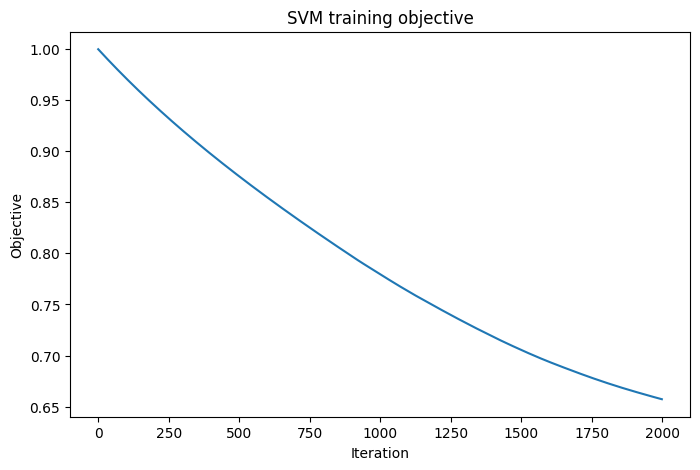

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(model.loss_history_)

plt.xlabel("Iteration")
plt.ylabel("Objective")
plt.title("SVM training objective")

plt.show()

### Visualizing the Decision Boundary

`X_train` has 8 features, so we can't plot the true 8-dimensional
boundary. `plot_svm_boundary` below plots the decision line and margins
against just the first two features (`x1`, `x2`), treating every other
feature as if it were held at its average value — which is a reasonable
simplification here since we standardized the features, so their mean is
already 0. Treat this as a rough 2D slice of the real boundary, not the
whole picture.


In [15]:
def plot_svm_boundary(model, X, y):
    plt.figure(figsize=(8, 6))

    plt.scatter(
        X[y == -1, 0],
        X[y == -1, 1],
        label="-1",
    )

    plt.scatter(
        X[y == 1, 0],
        X[y == 1, 1],
        label="+1",
    )

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x_values = np.linspace(x_min, x_max, 300)

    if abs(model.w_[1]) > 1e-12:
        decision_boundary = (
            -(model.w_[0] * x_values + model.b_)
            / model.w_[1]
        )

        upper_margin = (
            -(model.w_[0] * x_values + model.b_ - 1)
            / model.w_[1]
        )

        lower_margin = (
            -(model.w_[0] * x_values + model.b_ + 1)
            / model.w_[1]
        )

        plt.plot(x_values, decision_boundary, label="decision boundary")
        plt.plot(x_values, upper_margin, "--", label="margin")
        plt.plot(x_values, lower_margin, "--")

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("Linear SVM decision boundary")
    plt.legend()
    plt.show()

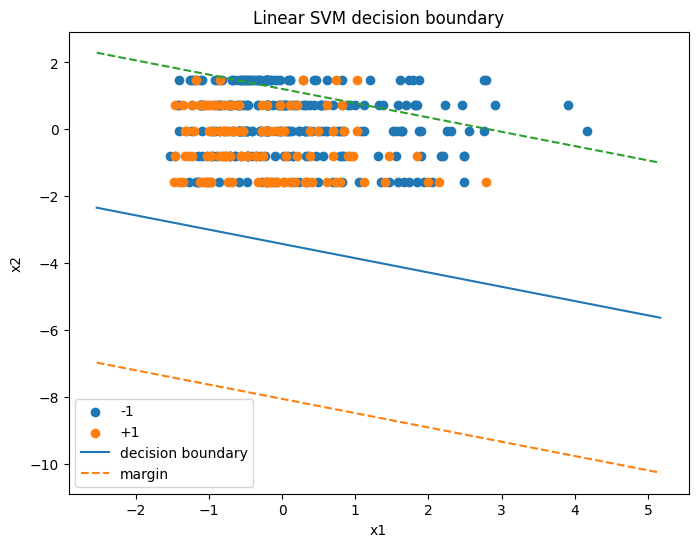

In [16]:
plot_svm_boundary(model, X_train, y_train)

## 6. Effect of the C Hyperparameter

Back in Section 1 we said `C` trades off margin width against how
strictly training points must satisfy the margin constraint:

- **Small `C`** → the margin term dominates → wider margin, more
  tolerance for violations → simpler decision boundary, less sensitive to
  individual points, but can underfit.
- **Large `C`** → the hinge-loss term dominates → the model works harder
  to classify every training point correctly, even at the cost of a
  narrow margin → can overfit, especially with noisy data.

Rather than take that on faith, let's train the scratch SVM across a
range of `C` values and see how test accuracy actually responds. Watch
for it to plateau or dip at the extremes rather than monotonically
improving — that's the overfitting/underfitting trade-off in action.


In [17]:
C_values = [0.01, 0.1, 1, 10, 100]
c_accuracies = []

for C in C_values:
    svm_c = LinearSVM(C=C, learning_rate=0.001, n_iters=2000)
    svm_c.fit(X_train, y_train)
    preds_c = svm_c.predict(X_test)
    c_accuracies.append(accuracy_score(y_test, preds_c))

for C, acc in zip(C_values, c_accuracies):
    print(f"C={C:<6} accuracy={acc:.3f}")


C=0.01   accuracy=0.720
C=0.1    accuracy=0.720
C=1      accuracy=0.720
C=10     accuracy=0.720
C=100    accuracy=0.670


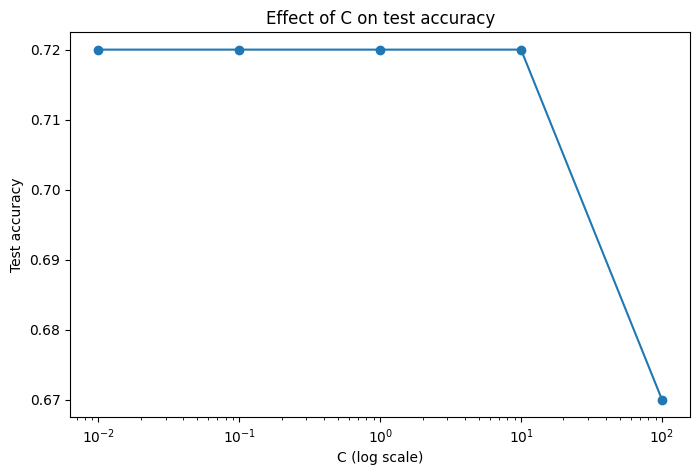

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(C_values, c_accuracies, marker="o")
plt.xscale("log")

plt.xlabel("C (log scale)")
plt.ylabel("Test accuracy")
plt.title("Effect of C on test accuracy")

plt.show()


## 7. Comparing to `sklearn.svm.SVC`

Finally, let's sanity-check our scratch implementation (at `C=1.0`)
against scikit-learn's linear SVM.

Don't expect the two to be identical. They're optimizing the *same*
objective but solving it differently: our `LinearSVM` runs (sub)gradient
descent directly on the primal objective for a fixed number of
iterations, while `sklearn.svm.SVC` solves the *dual* problem via
quadratic programming, run to a numerical convergence tolerance. Small
differences in the resulting `w`, `b`, or a percentage point or two of
accuracy are expected — a large, systematic gap would be the sign of a
bug, not just a difference in solver.


In [19]:
sklearn_model = SVC(kernel="linear", C=1.0)
sklearn_model.fit(X_train, y_train)

sklearn_pred = sklearn_model.predict(X_test)

print("Scratch SVM accuracy:", accuracy_score(y_test, y_pred))
print("sklearn SVM accuracy:", accuracy_score(y_test, sklearn_pred))


Scratch SVM accuracy: 0.72
sklearn SVM accuracy: 0.67


### Reflection

Answer these in your own words — they're meant to check that you
understand *why* the code works, not just that it runs and passes tests.
Refer back to the relevant section above if you get stuck.

1. Why does minimizing $\|w\|$ maximize the margin? *(Section 1)*
2. What does the hyperparameter $C$ control, and what did you actually
   observe in Section 6? *(Sections 1 and 6)*
3. What is the role of hinge loss — what would go wrong without it?
   *(Section 2)*
4. Why can two implementations produce slightly different values of
   $w$ while achieving similar predictions? *(Section 7)*
5. How does your scratch implementation differ from `sklearn.svm.SVC`,
   beyond just the accuracy numbers? *(Section 7)*
